## Root Mean Square Energy (RMSE) y Zero Crossing Rate (ZCR)

* En este notebook se hara uso de algunos de los audios de la base de datos *ravdess* que es la se utilizara para el procesamiento y objetivo final de este proyecto, los detalles acerca de este conjunto de audio y todos los objetivos del proyecto estan documentados a profundidad en el archivo Readme.md de este repositorio.
  
* Este es el primer notebook de este proyecto, donde vamos a explorar dos metodos de extracción de características como el Root Mean Square Energy (RMSE) y el Zero Crossing Rate (ZCR) ya que son fundamentales en el análisis de señales de audio, especialmente en tareas como la clasificación de sonidos, la detección de eventos acústicos y el reconocimiento de voz.

* El RMSE es una medida de la energía promedio de una señal de audio, calculada como la raíz cuadrada de la media de los cuadrados de las amplitudes de la señal. Es útil para identificar la intensidad de un sonido y puede ayudar a distinguir entre sonidos fuertes y suaves.

* El ZCR, por otro lado, mide la tasa de cruces por cero en una señal de audio. Es una característica importante para identificar la presencia de sonidos transitorios o ruidosos, ya que los sonidos con un alto ZCR suelen ser más ruidosos o tener una mayor cantidad de transitorios.

* Ambas características son ampliamente utilizadas en aplicaciones de procesamiento de audio y pueden ser combinadas con otras características para mejorar la precisión de los modelos de clasificación y reconocimiento de audio.


In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import IPython.display as ipd

In [ ]:
## Load audio files
BASE_DIR = "./Actor_01"
audio_file01 = os.path.join(BASE_DIR, "01.wav")
audio_file02 = os.path.join(BASE_DIR, "05.wav")
audio_file03 = os.path.join(BASE_DIR, "03.wav")

Realizamos la reproducción de los audios, de manera que podemos tratar de captar a travez de nuestra capacidad auditiva, las direfencias en el tono en que se pronuncia una misma frase. En los siguientes nootebooks se profundizara sobre las convenciones de nombrado de los archivos de audio en el conjunto de audio, pero por ahora es importante destacar que el audio01 corresponde a una frase pronunciada en un tono neutral, mientras que el audio02 corresponde a la misma frase pronunciada en un tono triste.

Puedes notar la diferencia a simple escucha ?


In [ ]:
ipd.Audio(audio_file01)

In [ ]:
ipd.Audio(audio_file02)

In [ ]:
# Sr recibe la frecuencia de muestreo (por defecto en Librosa es 22050)

audio01, sr = librosa.load(audio_file01)
audio02, _ = librosa.load(audio_file02)

### Root Mean Squeare con Librosa

In [ ]:
FRAME_SIZE = 1024 # Valores convencionales
HOP_LENGTH = 512

In [ ]:
# De antemano sabemos que audio01 es de caracter neutro, mientras que audio02 es de caracter triste.
rms_audio01 = librosa.feature.rms(y=audio01, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]
rms_audio02 = librosa.feature.rms(y=audio02, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]


### Visualizando RMSE + waveform

In [ ]:
frames = range(len(rms_audio01))
frames_b = range(len(rms_audio02))
t = librosa.frames_to_time(frames, hop_length=HOP_LENGTH)
t2 = librosa.frames_to_time(frames_b, hop_length=HOP_LENGTH)


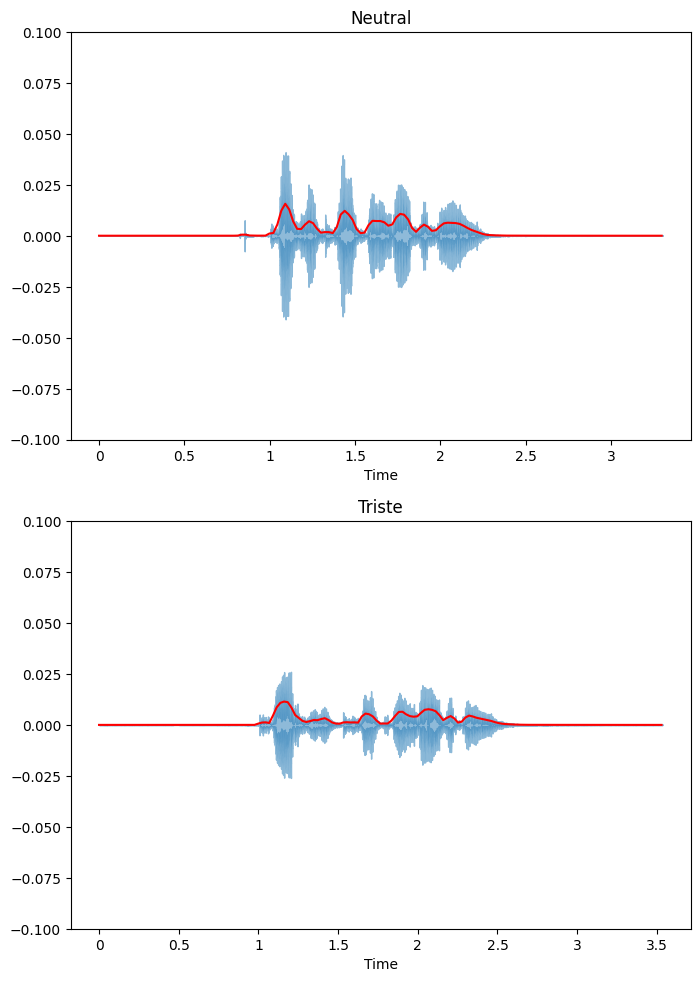

In [ ]:
# La energia de la señal se representa con una curva roja sobre la forma de onda.

plt.figure(figsize=(8, 18))

ax = plt.subplot(3, 1, 1)
librosa.display.waveshow(audio01, alpha=0.5)
plt.plot(t, rms_audio01, color="r")
plt.ylim((-0.1, 0.1))
plt.title("Neutral")

plt.subplot(3, 1, 2)
librosa.display.waveshow(audio02, alpha=0.5)
plt.plot(t2, rms_audio02, color="r")
plt.ylim((-0.1, 0.1))
plt.title("Triste")


plt.show()

Visualmente RMSE es una herramienta que nos permite de manera preliminar indentificar la energía de un sonido en un instanten de tiempo, es decir, nos permite identificar la intensidad de un sonido, lo que puede ser útil para distinguir entre sonidos fuertes y suaves. En este caso podemos observar que el audio02 tiene una **mayor energía** que el audio01, lo que es consistente con la percepción de que el audio02 tiene un timbre mas triste que el audio01.

###  Zero Crossing Rate (ZCR) con Librosa

In [ ]:
zcr_audio01 = librosa.feature.zero_crossing_rate(y=audio01, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]
zcr_audio02 = librosa.feature.zero_crossing_rate(y=audio02, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]

(0.0, 1.0)

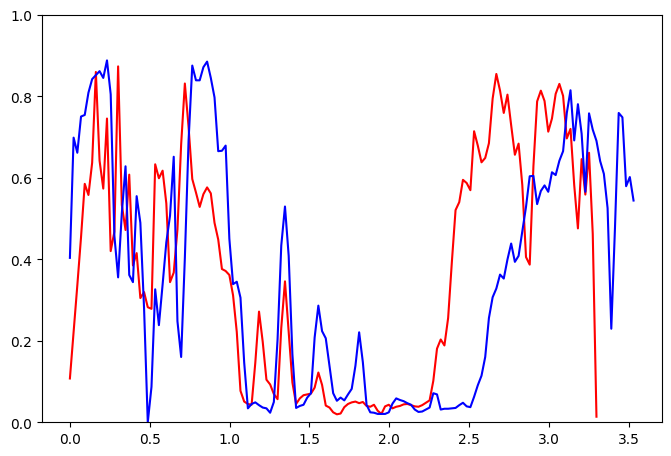

In [ ]:
plt.figure(figsize=(8, 18))

ax = plt.subplot(3, 1, 1)
plt.plot(t, zcr_audio01, color="r")
plt.ylim((0, 1))

ax = plt.subplot(3, 1, 1)
plt.plot(t2, zcr_audio02, color="b")
plt.ylim((0, 1))


Como se obvserva en la gráfica de color azul correspondiente al audio02 (triste),el ZCR aparentemente está mas precente, esto indica que tiene una mayor cantidad de transitorios o ruidos, mas sin embargo no nos permite caractizar o direfenciar de manera intuitiva el tono de la voz entre las dos muestras, por lo que esta claro que, esta caracteristica suele ser mas util brindando información complementaria en conjunto con tecnicas  como el RMSE, MFCC, etc.